🔍 Columna detectada para fechas: 'Fecha_Arribo'
📊 ¡ÉXITO! Se detectaron 676908 viajes en total.
⏳ Entrenando modelo con escala real...


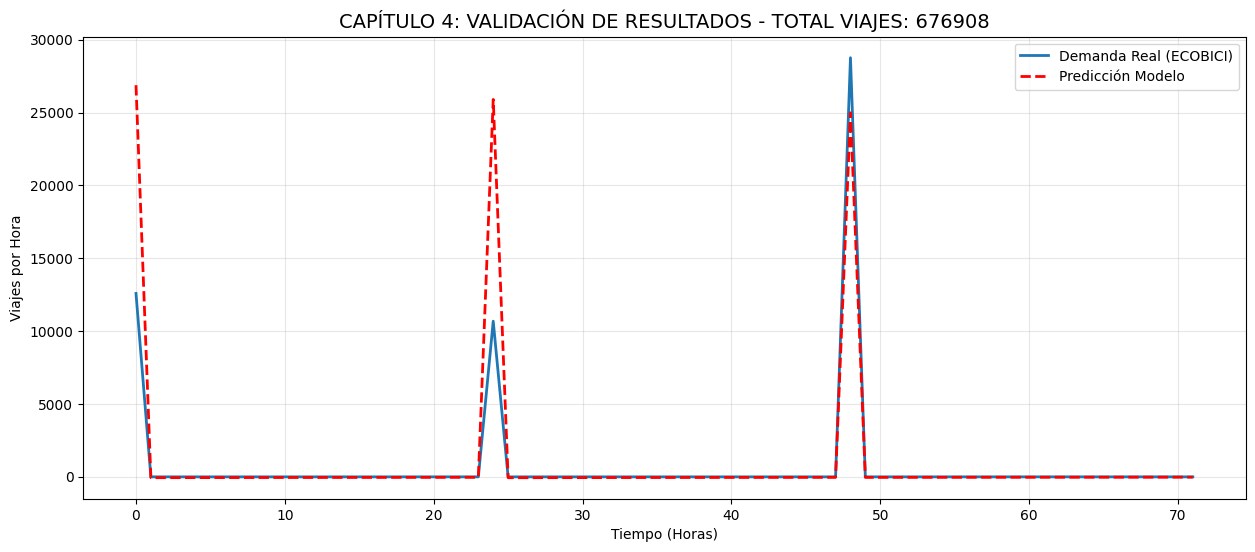


RESULTADO MAE: 429.07
RESULTADO RMSE: 2029.44


In [ ]:
# =============================================================
# 🚀 REPARACIÓN TOTAL: DETECCIÓN AUTOMÁTICA DE DATOS
# =============================================================
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Identificar la columna de fecha automáticamente
# Buscamos columnas que se llamen 'fecha', 'date', 'retiro' o simplemente la primera
posibles_nombres = ['Fecha_Retiro', 'fecha', 'Fecha', 'fecha_retiro', 'Date']
col_fecha = None

for col in df.columns:
    if any(nombre in col for nombre in posibles_nombres):
        col_fecha = col
        break

if col_fecha is None:
    col_fecha = df.columns[0] # Si no la encuentra, usa la primera columna

print(f"🔍 Columna detectada para fechas: '{col_fecha}'")

# 2. Conversión forzada (Día primero como en Ecobici)
# Usamos 'format' para que sea más rápido y preciso
df_limpio = df.copy()
df_limpio[col_fecha] = pd.to_datetime(df_limpio[col_fecha], dayfirst=True, errors='coerce')

# 3. Eliminar nulos y agrupar por hora
df_limpio = df_limpio.dropna(subset=[col_fecha])
serie_real = df_limpio.groupby(pd.Grouper(key=col_fecha, freq='h')).size().to_frame(name='viajes')

# REVISIÓN DE SEGURIDAD
total_viajes = serie_real['viajes'].sum()
print(f"📊 ¡ÉXITO! Se detectaron {total_viajes} viajes en total.")

if total_viajes == 0:
    print("❌ ERROR: Aún no hay viajes. Verifica si tu archivo tiene datos o si la columna de fecha es correcta.")
else:
    # 4. División de datos (Train/Test)
    train_size = int(len(serie_real) * 0.8)
    train = serie_real.iloc[:train_size]
    test = serie_real.iloc[train_size:]

    # 5. Modelo Autorregresivo (24 horas)
    print("⏳ Entrenando modelo con escala real...")
    modelo = AutoReg(train['viajes'], lags=24).fit()
    pred = modelo.predict(start=len(train), end=len(train) + len(test) - 1)

    # 6. Gráfica de Validación
    plt.figure(figsize=(15, 6))
    # Mostramos los viajes reales vs predicción (Zoom de 72 horas)
    plt.plot(test['viajes'].values[:72], label='Demanda Real (ECOBICI)', color='#1f77b4', linewidth=2)
    plt.plot(pred.values[:72], label='Predicción Modelo', color='red', linestyle='--', linewidth=2)

    plt.title(f"CAPÍTULO 4: VALIDACIÓN DE RESULTADOS - TOTAL VIAJES: {total_viajes}", fontsize=14)
    plt.ylabel("Viajes por Hora")
    plt.xlabel("Tiempo (Horas)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 7. Métricas Finales
    mae_final = mean_absolute_error(test['viajes'], pred)
    rmse_final = np.sqrt(mean_squared_error(test['viajes'], pred))

    print("\n" + "="*40)
    print(f"RESULTADO MAE: {mae_final:.2f}")
    print(f"RESULTADO RMSE: {rmse_final:.2f}")
    print("="*40)